In [2]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
import numpy as np
import pandas as pd 
from scipy.spatial.transform import Rotation as R
from scipy.spatial.distance import pdist, squareform
from pathlib import Path 
import tqdm
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches


In [3]:
def xyz_to_rdkit_mol(xyz_file, total_charge):
    """
    Convert an XYZ file with explicit hydrogens to an RDKit Mol,
    preserving 3D coordinates and determining connectivity automatically.
    

    Parameters:
        xyz_file: path to XYZ file
        total_charge: total molecular charge (default 0)
    
    Returns:
        RDKit Mol object
    """
    # --- Read XYZ ---
    with open(xyz_file) as f:
        lines = f.readlines()[2:]  # skip atom count + comment
    atoms, coords = [], []

    for line in lines:
        parts = line.split()
        atoms.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    coords = np.array(coords)
    
    # --- Create empty molecule with atoms ---
    mol = Chem.RWMol()
    z = [Chem.GetPeriodicTable().GetAtomicNumber(a) for a in atoms]
    for Zi in z:
        mol.AddAtom(Chem.Atom(Zi))
    
    # --- Add coordinates ---
    conf = Chem.Conformer(len(coords))
    for i, pos in enumerate(coords):
        conf.SetAtomPosition(i, pos)
    mol.AddConformer(conf)
    
    # --- Determine connectivity using RDKit's bond perception ---
    Chem.rdDetermineBonds.DetermineConnectivity(mol, charge=total_charge)
    
    # --- Sanitize molecule ---
    Chem.SanitizeMol(mol)
    
    return mol




In [4]:
raw_spawns_folder = Path('../../../data/raw_geometries/spawn/benzene/S1S0')
mecis = [ 
   Path('../../../data/raw_geometries/meci/benzene_main_meci/Type 1.xyz'),
    Path('../../../data/raw_geometries/meci/benzene_main_meci/Type 2.xyz'),
    Path('../../../data/raw_geometries/meci/benzene_main_meci/Type 3.xyz'),
    
]


In [5]:
idx = []
list_of_sorted_eigenvalues = []

smiles = []

for x in tqdm.tqdm(list(raw_spawns_folder.glob('*'))):
    mol = xyz_to_rdkit_mol(x,total_charge=0)
    smile = Chem.MolToSmiles(mol, canonical=True)

    matrix = 1 / ( Chem.Get3DDistanceMatrix(mol) + .001)
    eigenvalues = np.linalg.eigvals(matrix)
    sorted_eigenvalues = np.sort(eigenvalues)
    idx.append(x.stem)
    list_of_sorted_eigenvalues.append(sorted_eigenvalues)
    smiles.append(smile)


for meci in mecis:

    mol = xyz_to_rdkit_mol(meci,total_charge=0)
    matrix = 1 / ( Chem.Get3DDistanceMatrix(mol) + .001)
    smile = Chem.MolToSmiles(mol, canonical=True)

    eigenvalues = np.linalg.eigvals(matrix)
    sorted_eigenvalues = np.sort(eigenvalues)
    list_of_sorted_eigenvalues.append(sorted_eigenvalues)
    smiles.append(smile)
    idx.append(meci.stem)

feature_vector = np.array(list_of_sorted_eigenvalues)







  0%|          | 0/1190 [00:00<?, ?it/s]

100%|██████████| 1190/1190 [00:00<00:00, 4805.33it/s]


In [7]:



reduction_technique = 'UMAP'


In [8]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pydiffmap import diffusion_map as dm






if reduction_technique.upper() == 'TSNE':
    reducer = TSNE(
        n_components=2,
        perplexity=10,      
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    reduced_space = reducer.fit_transform(feature_vector)

elif reduction_technique.upper() == 'PCA':
    reducer = PCA(
        n_components=2,
        random_state=42
    )   
    reduced_space = reducer.fit_transform(feature_vector)

elif reduction_technique.upper() == 'UMAP':
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=10,
        min_dist=0.1,
        random_state=42
    )
    reduced_space = reducer.fit_transform(feature_vector)

elif reduction_technique == 'Diffusion_Map':
    n_components = 2
    alpha = 0.5   
    mydmap = dm.DiffusionMap.from_sklearn(n_evecs=n_components, alpha=alpha)
    reduced_space = mydmap.fit_transform(feature_vector)

else:
    raise ValueError(f"Unknown reduction technique: {reduction_technique}")

print(f"Reduced space shape: {reduced_space.shape}")



/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced space shape: (1193, 2)


/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_42983/1591750378.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


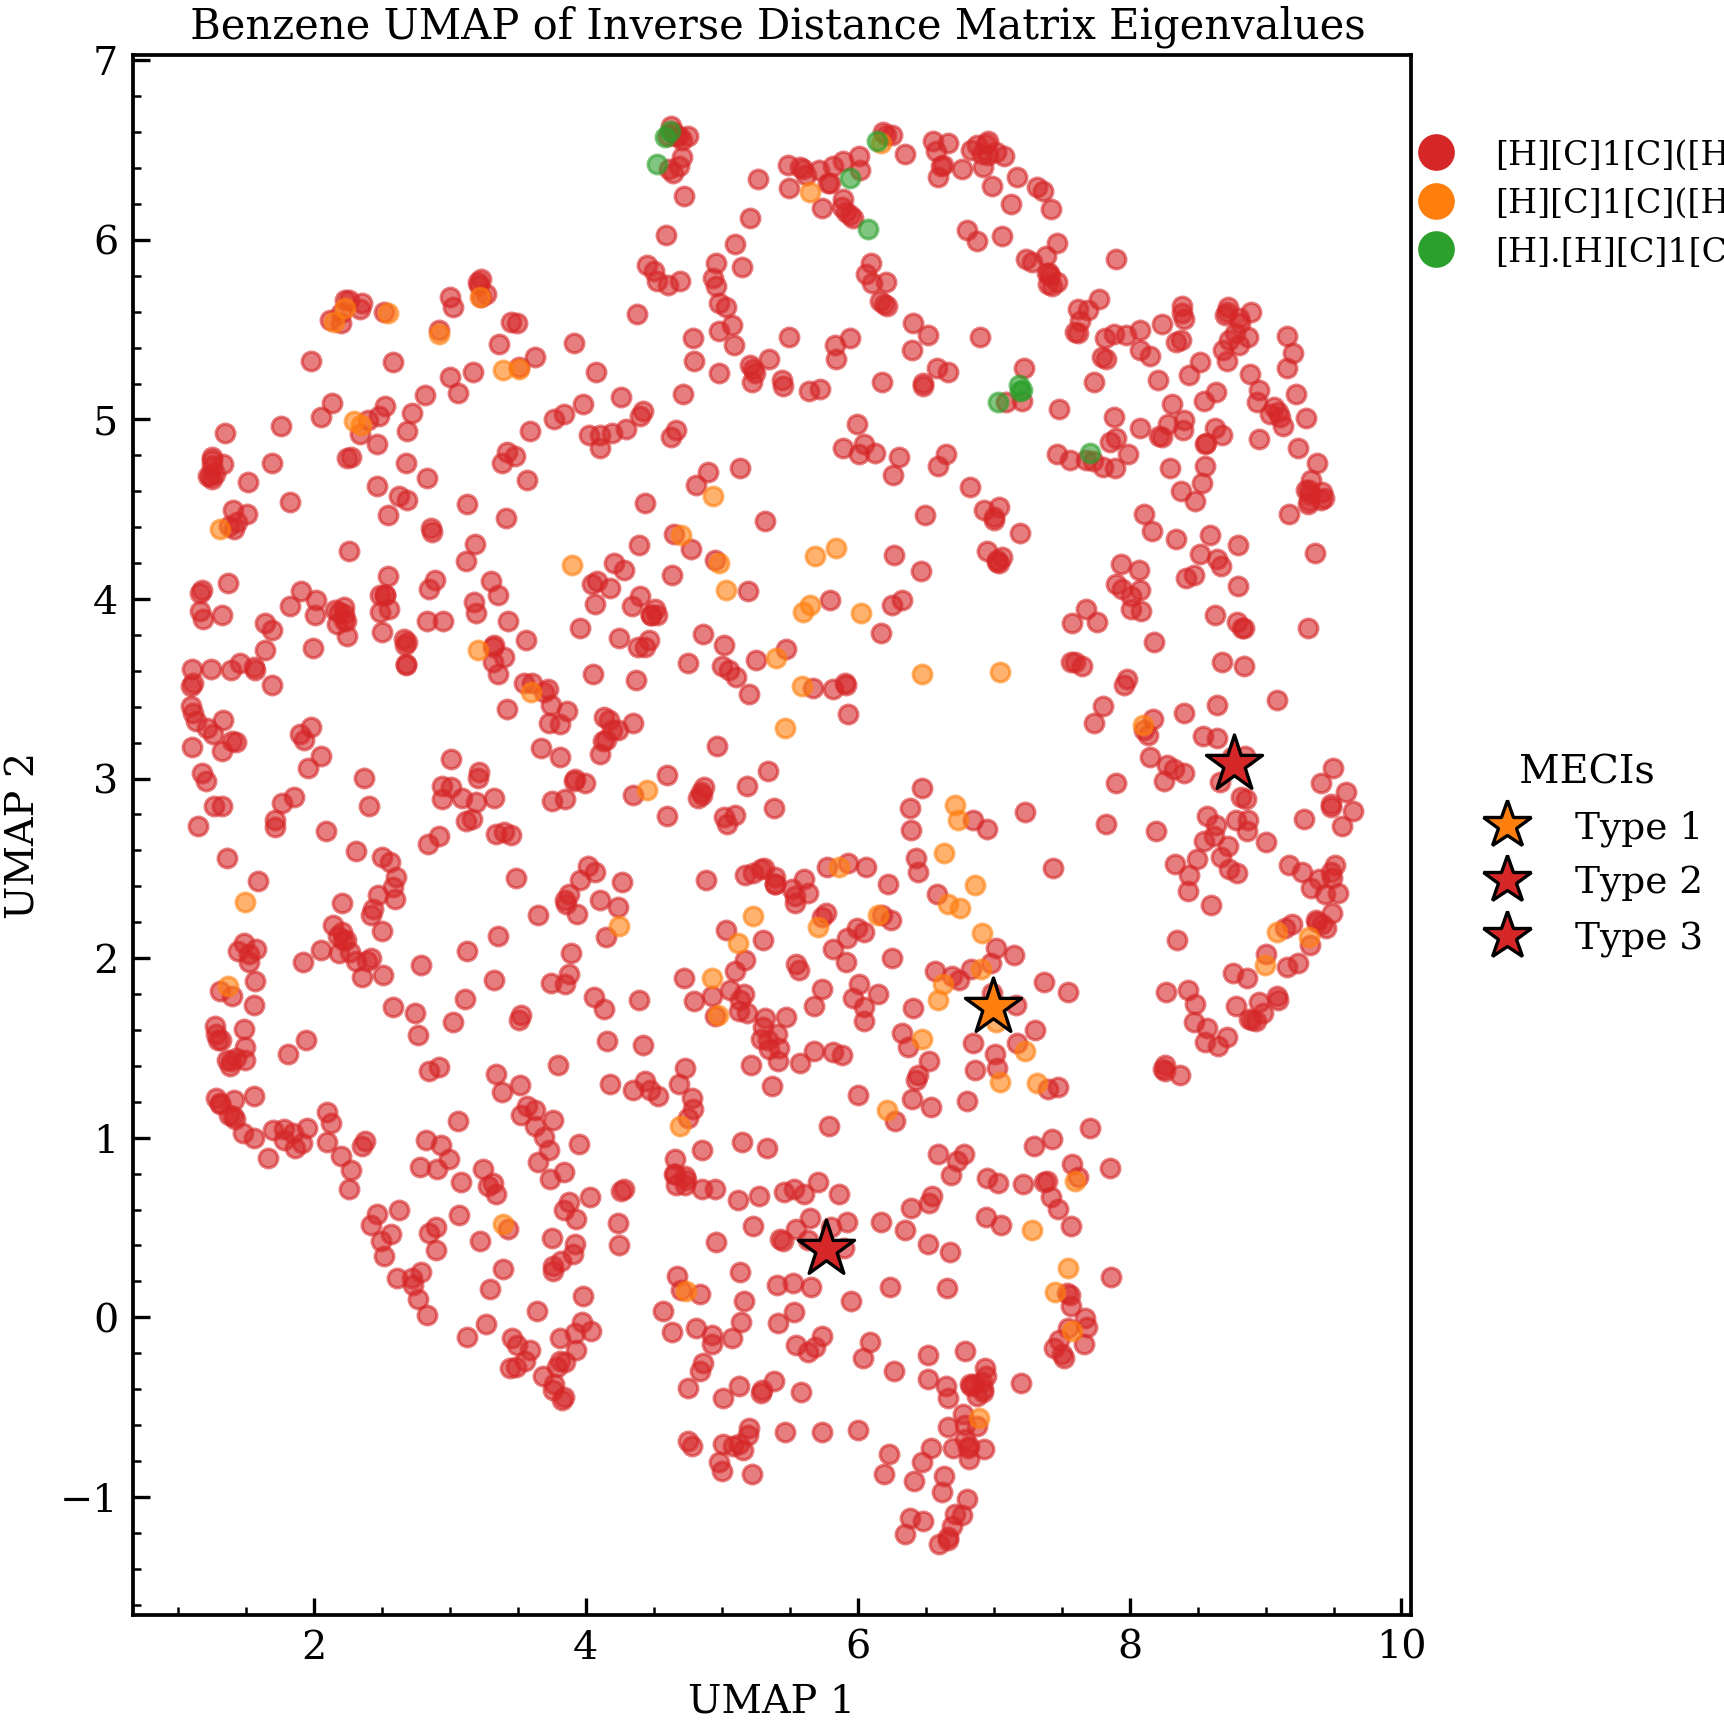

In [9]:


n_spawns = len(list(raw_spawns_folder.glob('*')))

X_spawns = reduced_space[:n_spawns]
X_mecis  = reduced_space[n_spawns:]

smiles_spawns = smiles[:n_spawns]
smiles_mecis  = smiles[n_spawns:]
idx_mecis     = idx[n_spawns:]

unique_smiles = list(dict.fromkeys(smiles))

plt.style.use("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/prl.mplstyle")


color_list = [
    "tab:red",
    "tab:orange",
    "tab:green",
    "tab:blue",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]

# safety check
if len(unique_smiles) > len(color_list):
    raise ValueError("Not enough colors for number of unique SMILES")

smiles_to_color = {
    smi: color_list[i]
    for i, smi in enumerate(unique_smiles)
}

fig, ax = plt.subplots(figsize=(6, 6))

for smi in unique_smiles:
    mask = [s == smi for s in smiles_spawns]
    ax.scatter(
        X_spawns[mask, 0],
        X_spawns[mask, 1],
        color=smiles_to_color[smi],
        s=20,
        alpha=0.6
    )

for (x, y), smi in zip(X_mecis, smiles_mecis):
    ax.scatter(
        x, y,
        marker="*",
        s=200,
        color=smiles_to_color[smi],
        edgecolor="k",
        linewidth=0.8
    )


smiles_handles = [
    plt.Line2D(
        [], [],
        marker='o',
        linestyle='',
        color=smiles_to_color[smi],
        label=smi,
        markersize=8
    )
    for smi in unique_smiles
]

legend_smiles = ax.legend(
    handles=smiles_handles,
    title="SMILES",
    loc="upper left",
    bbox_to_anchor=(0.97, 1),
    fontsize=8
)
ax.add_artist(legend_smiles)


meci_handles = [
    plt.Line2D(
        [], [],
        marker='*',
        linestyle='',
        color=smiles_to_color[smi],
        markeredgecolor='k',
        markeredgewidth=0.8,
        label=name,
        markersize=12
    )
    for name, smi in zip(idx_mecis, smiles_mecis)
]

ax.legend(
    handles=meci_handles,
    title="MECIs",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.4)
)

# -------------------------------
# labels / layout
# -------------------------------
ax.set_xlabel(f"{reduction_technique} 1")
ax.set_ylabel(f"{reduction_technique} 2")
ax.set_title(f" Benzene {reduction_technique} of Inverse Distance Matrix Eigenvalues")

plt.tight_layout()
plt.show()


/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_42983/1647194092.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


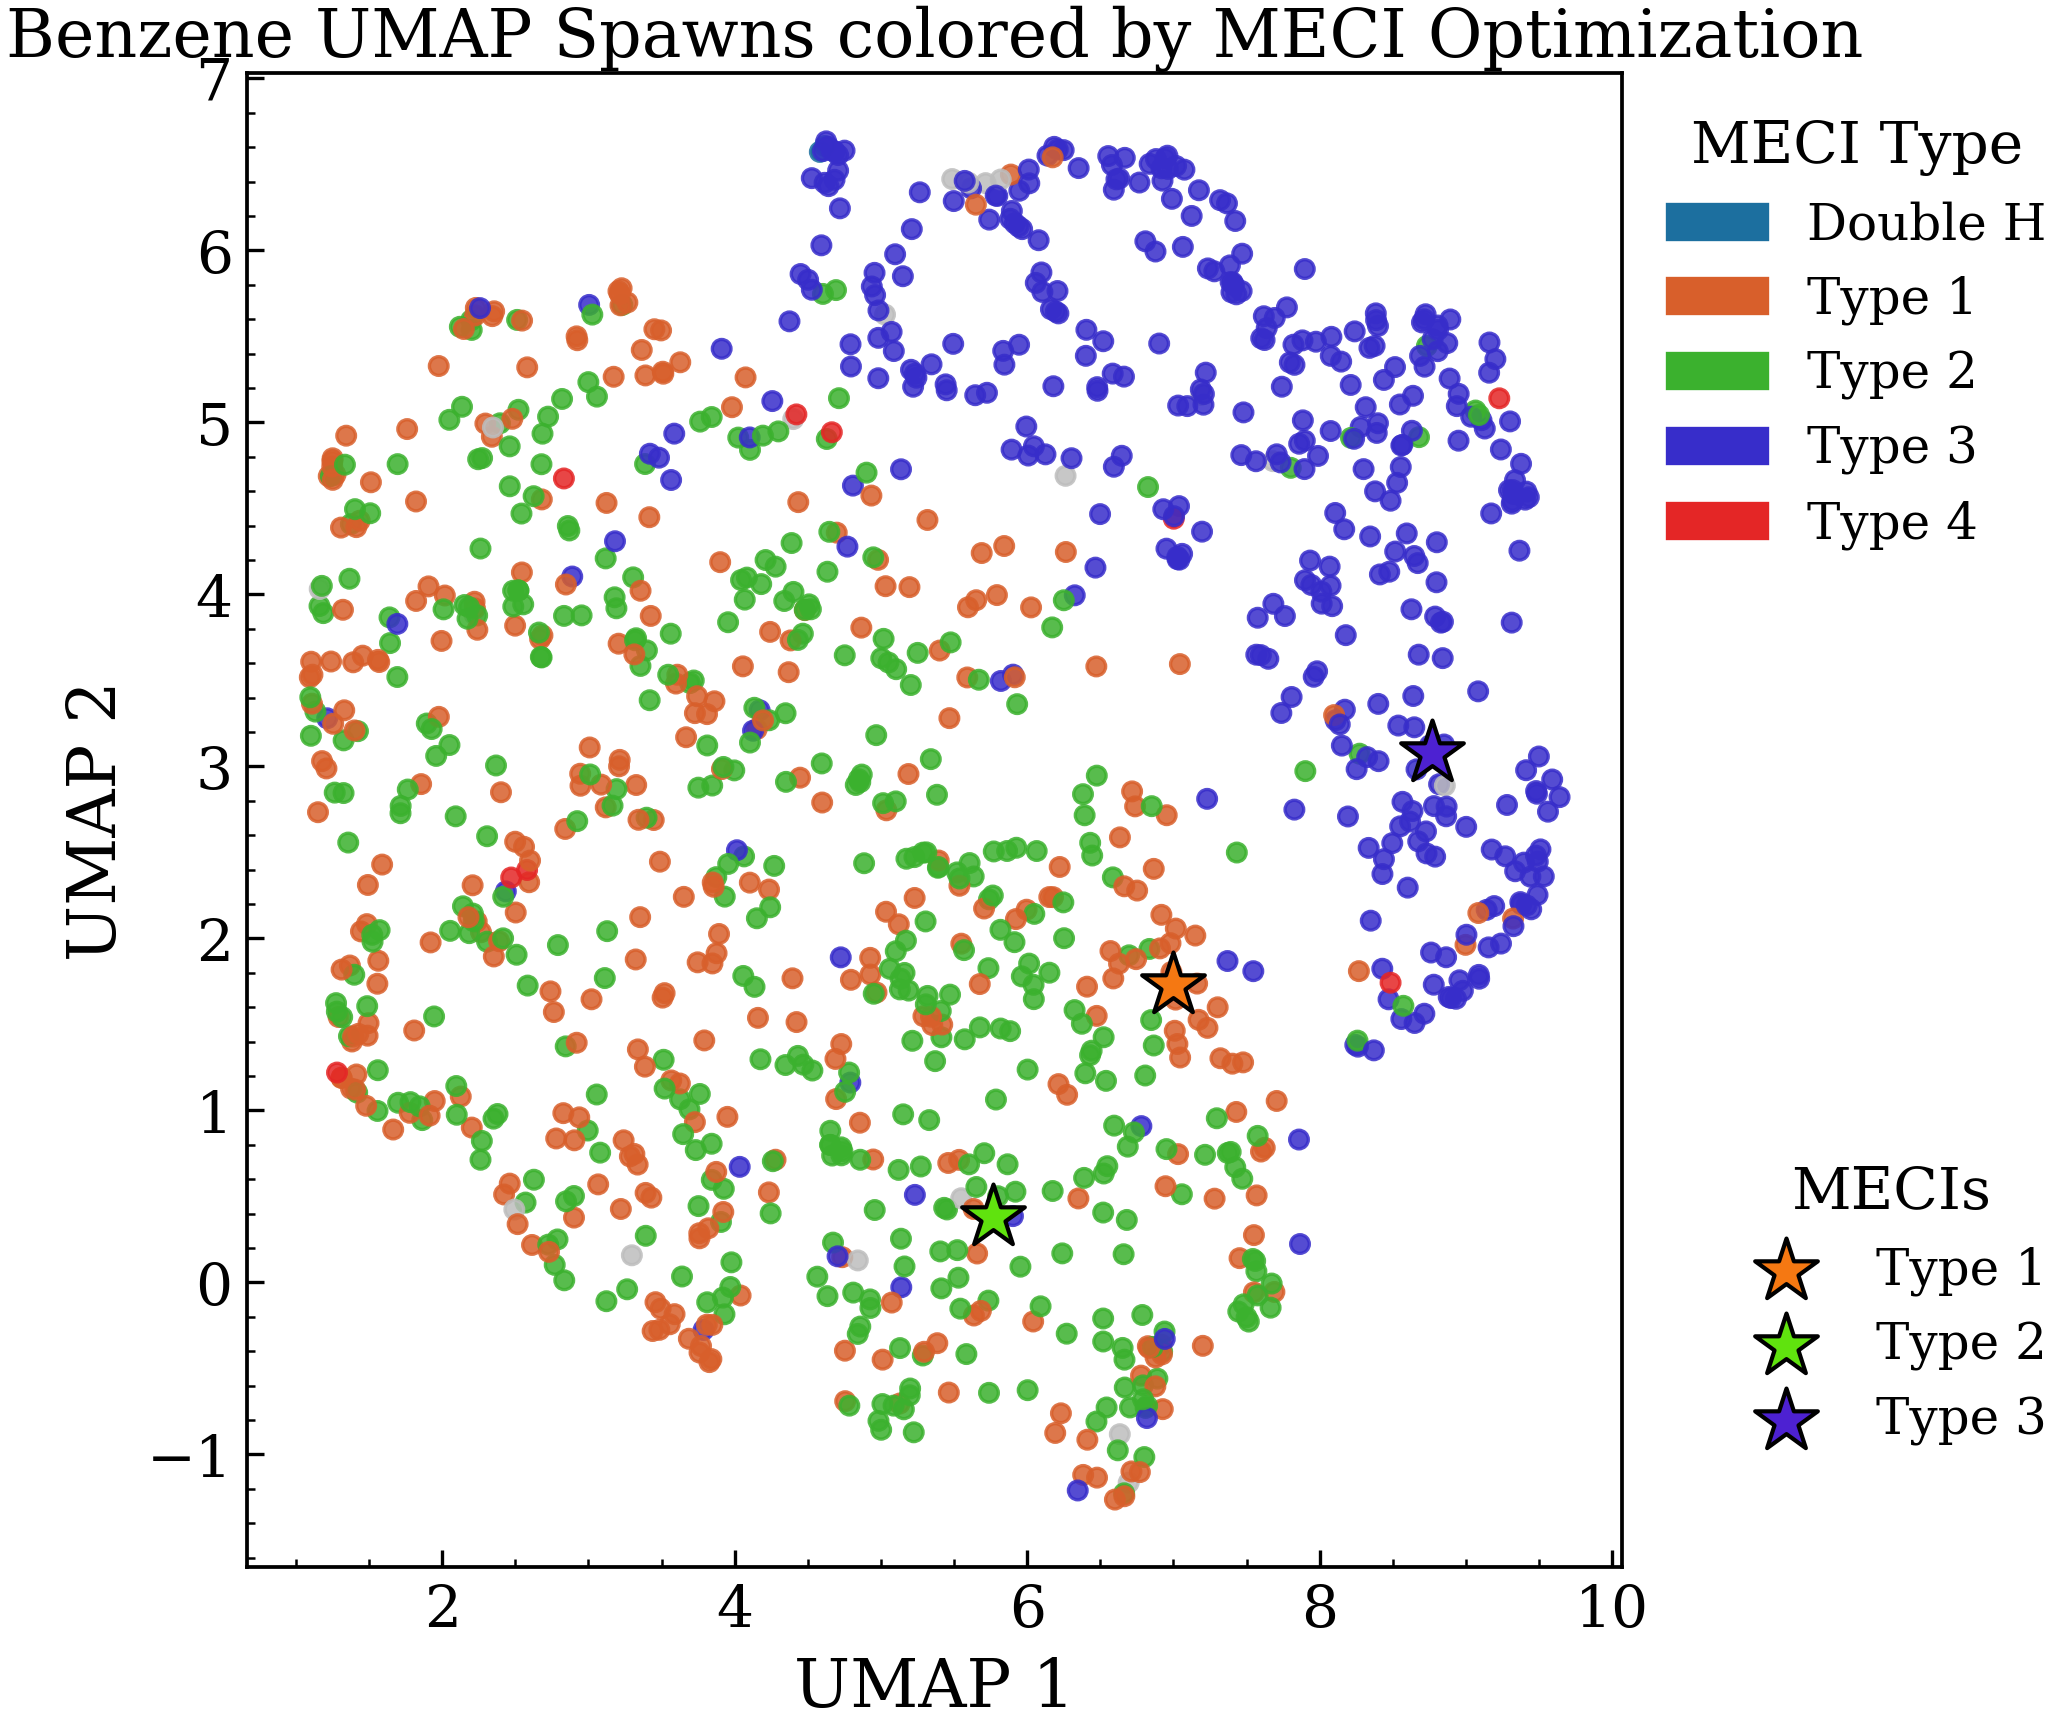

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

csv_file = "../../../data/meci_classification/benzene/S1S0/meci_labels_humanlabels.csv"
n_star = len(mecis)
star_size = 250
point_size = 20

base_colors = ["#1c6f9f", "#d85f2b", "#3bb12e", "#372dca", "#e42626", "#800080", "#00ced1", "#15bad4", "#60ca97", "#1a45bb"]
star_edgecolor = "black"

df = pd.read_csv(csv_file)

meci_idx_to_type = dict(zip(df['idx'], df['meci_type']))

unique_types = sorted(df['meci_type'].unique())
type_to_color = {t: base_colors[i % len(base_colors)] for i, t in enumerate(unique_types)}

point_types = [meci_idx_to_type.get(i, "Unknown") for i in idx]
point_colors = [type_to_color.get(t, "#bdbdbd") for t in point_types]


star_colors_dict = {
    idx[-4]: "#0075f3",  
    idx[-3]: "#f57812", 
    idx[-2]: "#60e30e",  
    idx[-1]: "#4d21d2", 

}

plt.figure(figsize=(7,6))
plt.scatter(reduced_space[:,0], reduced_space[:,1], c=point_colors, s=point_size, alpha=0.85)

star_indices = np.arange(len(reduced_space) - n_star, len(reduced_space))
star_handles = []
for star_idx in star_indices:
    star_color = star_colors_dict.get(idx[star_idx], point_colors[star_idx])
    h = plt.scatter(
        reduced_space[star_idx,0],
        reduced_space[star_idx,1],
        marker="*",
        s=star_size,
        color=star_color,
        edgecolor=star_edgecolor,
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx])
    )
    star_handles.append(h)

type_patches = [mpatches.Patch(color=color, label=t) for t, color in type_to_color.items()]
type_legend = plt.legend(handles=type_patches, title="MECI Type", bbox_to_anchor=(1.0, 1),
                         loc="upper left", title_fontsize=14, fontsize=12)
plt.gca().add_artist(type_legend)

star_legend = plt.legend(handles=star_handles, title="MECIs", bbox_to_anchor=(1.05, 0.3),
                        loc="upper left", title_fontsize=14, fontsize=12)

plt.xlabel(f"{reduction_technique} 1", fontsize=16)
plt.ylabel(f"{reduction_technique} 2", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"Benzene {reduction_technique} Spawns colored by MECI Optimization", fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anac

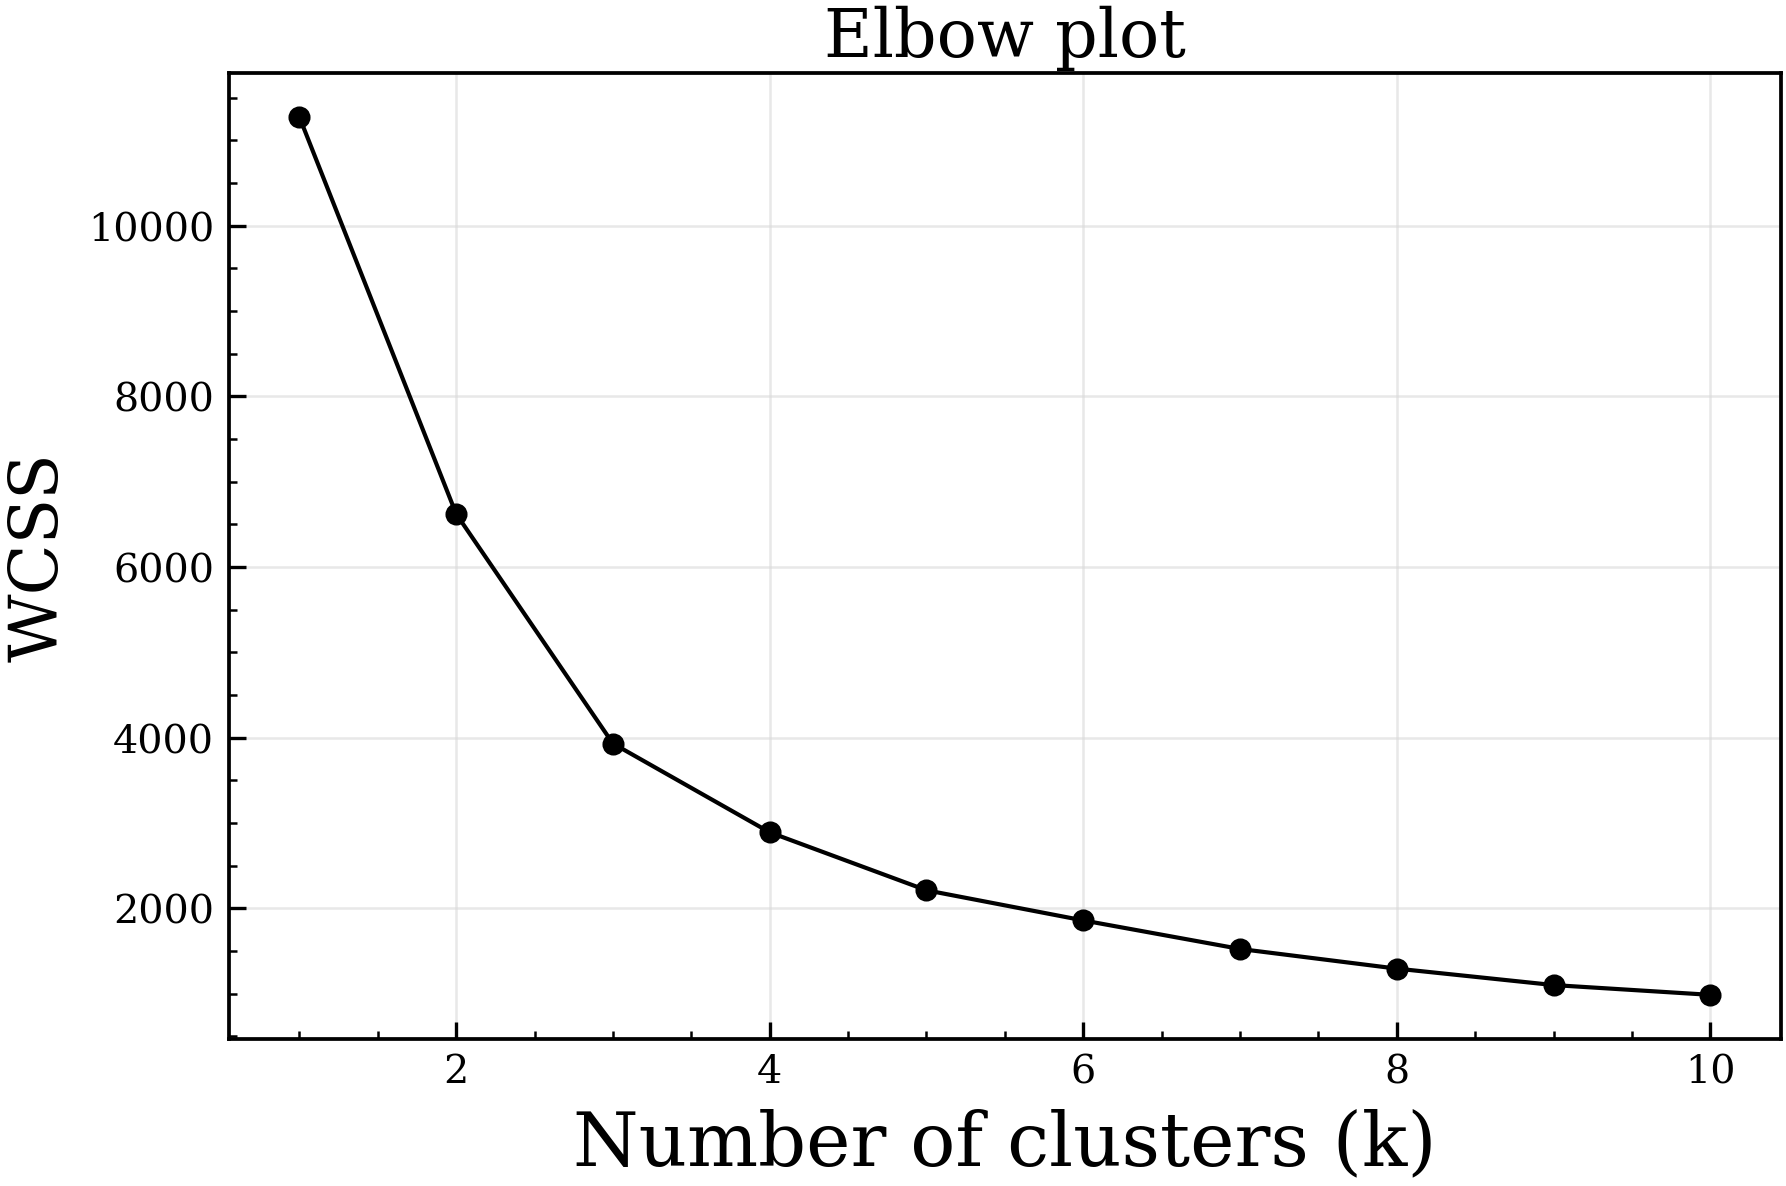

In [11]:
wcss = []
k_range = range(1, min(11, len(reduced_space)))
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(reduced_space)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)", fontsize=18)
plt.ylabel("WCSS",fontsize=16)
plt.title(f"Elbow plot", fontsize=16)
plt.grid(True)
plt.show()

/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_42983/4228692620.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


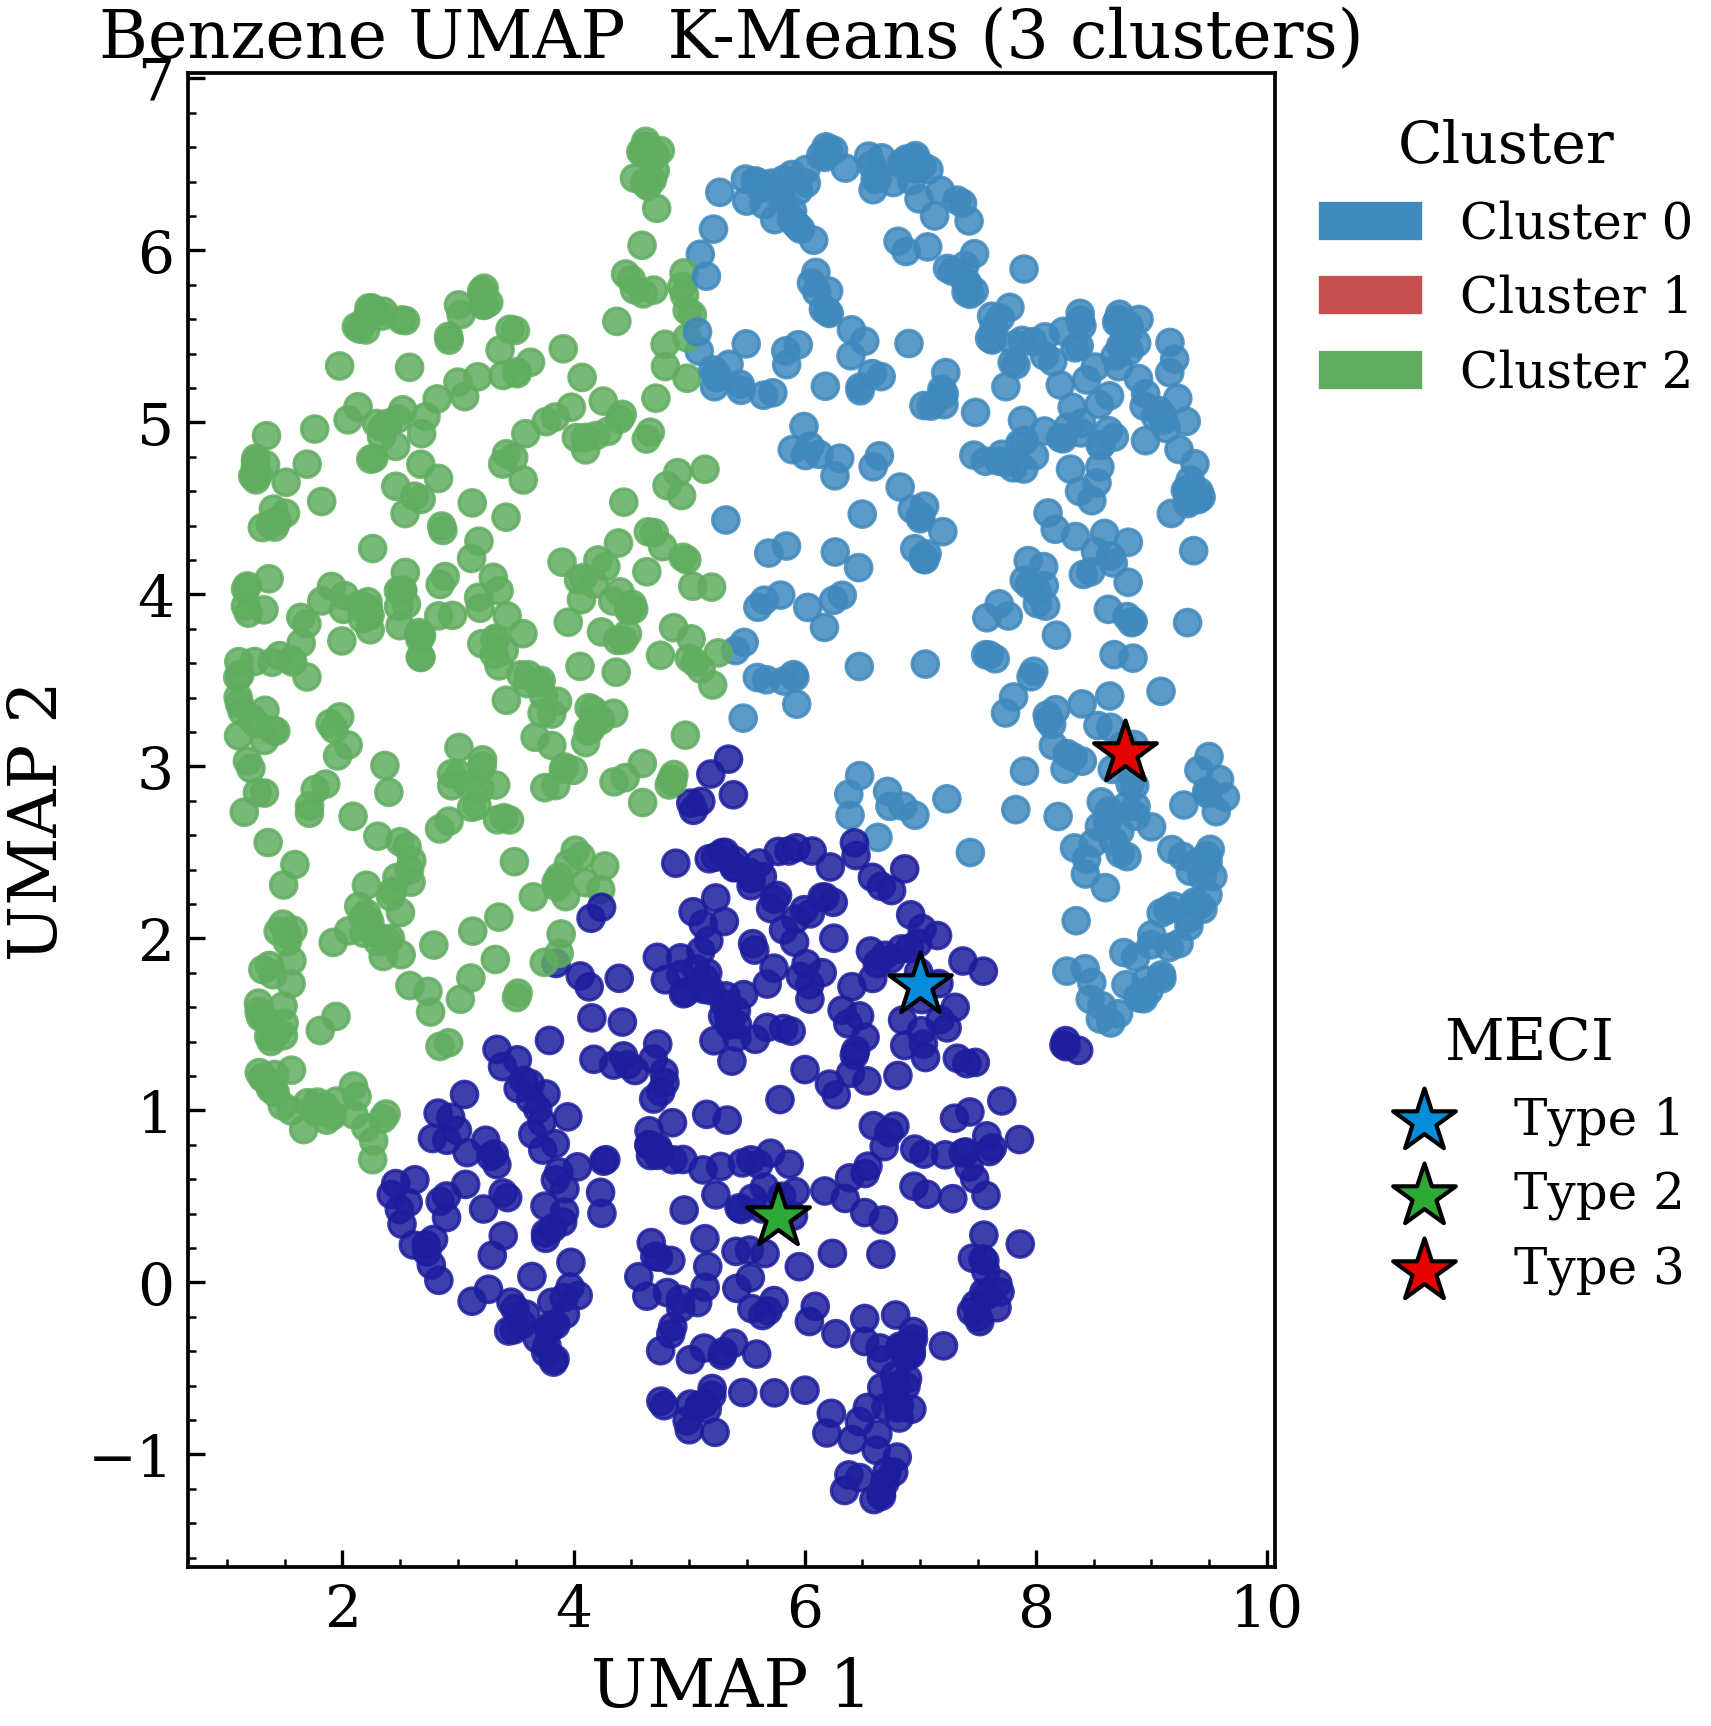

In [20]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(reduced_space)

output_rows =[]

for idx_val, cluster_val in zip(idx, labels):
    output_rows.append([idx_val.stem if isinstance(idx_val, Path) else str(idx_val),
                        cluster_val])


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np

n_star = 3                   
star_size = 250
point_size = 40

cluster_colors = [
    "#3f89bd",  # cluster 0
    "#c65050",  # cluster 1
    "#60ad60", 
    "#1d1d9e",  # cluster 2
]

# ⭐ Manually chosen star colors (one per starred point, in order)
star_colors = [
    "#068cda",  # red
    "#2daa36",  # purple
    "#e40202",  # green
    "#f98807",  # green

]

cmap = ListedColormap(cluster_colors)

# Indices of starred points (last n)
star_indices = np.arange(len(reduced_space) - n_star, len(reduced_space))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 6))

# Normal points
plt.scatter(
    reduced_space[:, 0],
    reduced_space[:, 1],
    c=labels,
    cmap=cmap,
    s=point_size,
    alpha=0.85
)

# Starred points (plotted on top)
star_handles = []
for i, star_idx in enumerate(star_indices):
    h = plt.scatter(
        reduced_space[star_idx, 0],
        reduced_space[star_idx, 1],
        marker="*",
        s=star_size,
        color=star_colors[i],   # ⭐ manual color
        edgecolor="black",
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx].stem if hasattr(idx[star_idx], "stem") else idx[star_idx])
    )
    star_handles.append(h)

# -----------------------------
# Labels & formatting
# -----------------------------
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"Benzene {reduction_technique}  K-Means ({optimal_k} clusters)", fontsize=16)
plt.xlabel(f"{reduction_technique} 1", fontsize=16)
plt.ylabel(f"{reduction_technique} 2", fontsize=16)
plt.grid(False)

# -----------------------------
# Legends
# -----------------------------
# Cluster legend
cluster_patches = [
    mpatches.Patch(color=cluster_colors[i], label=f"Cluster {i}")
    for i in sorted(set(labels))
]

cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Cluster",
    bbox_to_anchor=(1.0, 1),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)

# Star legend (idx names)
star_legend = plt.legend(
    handles=star_handles,
    title="MECI",
    bbox_to_anchor=(1.05, 0.4),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)

plt.gca().add_artist(cluster_legend)

plt.tight_layout()
plt.show()


In [16]:
print(output_rows)

[['0648_2', np.int32(1)], ['0470_3', np.int32(1)], ['0299_2', np.int32(2)], ['0435_3', np.int32(1)], ['0572_4', np.int32(0)], ['0022_5', np.int32(1)], ['0861_5', np.int32(2)], ['0318_3', np.int32(1)], ['0120_2', np.int32(0)], ['0165_2', np.int32(0)], ['0926_2', np.int32(2)], ['0198_2', np.int32(1)], ['0771_3', np.int32(0)], ['0549_2', np.int32(1)], ['0734_3', np.int32(2)], ['0636_4', np.int32(1)], ['0673_4', np.int32(0)], ['0221_2', np.int32(1)], ['0019_3', np.int32(0)], ['0264_2', np.int32(0)], ['0013_13', np.int32(2)], ['0513_5', np.int32(2)], ['0187_5', np.int32(2)], ['0454_2', np.int32(2)], ['0085_2', np.int32(1)], ['0411_2', np.int32(2)], ['0629_3', np.int32(2)], ['0535_6', np.int32(2)], ['0947_3', np.int32(2)], ['0104_3', np.int32(2)], ['0902_3', np.int32(1)], ['0141_3', np.int32(2)], ['0590_3', np.int32(2)], ['0379_2', np.int32(0)], ['0845_4', np.int32(0)], ['0006_4', np.int32(0)], ['0612_5', np.int32(2)], ['0384_2', np.int32(0)], ['0755_2', np.int32(1)], ['0710_2', np.int32(2)]

In [15]:
df = pd.DataFrame(output_rows, columns=["idx", "cluster"])
csv_path = "../../..//data/clustered/no_smiles/inv_eigenvals/umap/kmeans/benzene/cluster_assignments.csv"
df.to_csv(csv_path, index=False)


HDBSCAN found 2 clusters, noise points: 430


/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_42983/2820189587.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


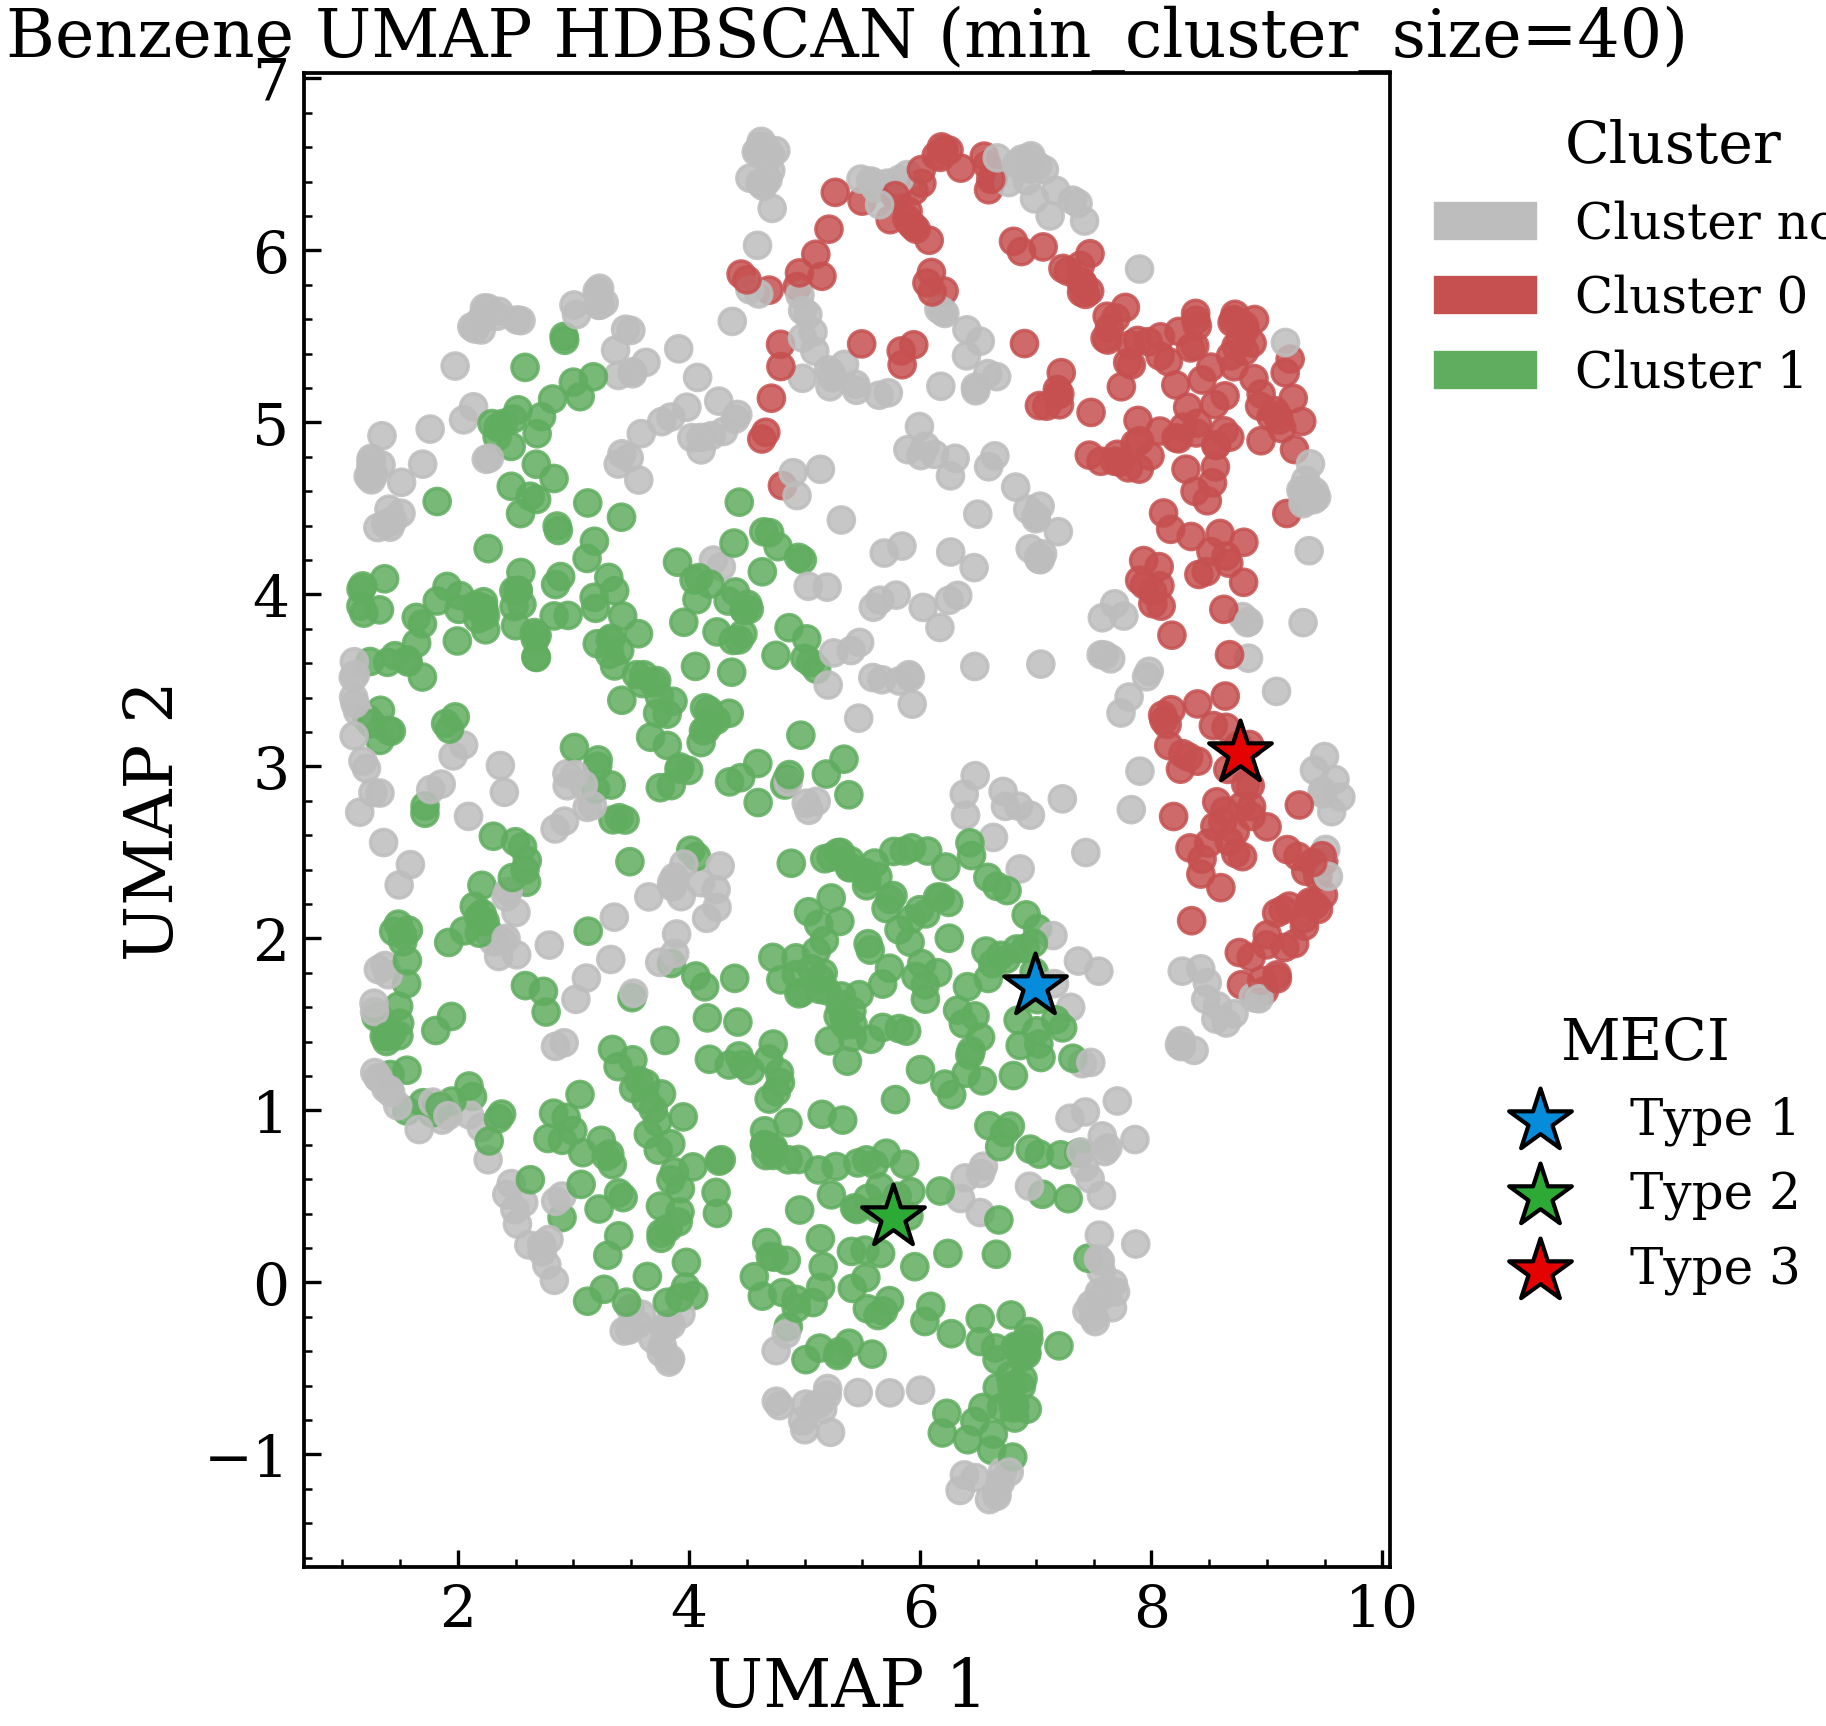

In [21]:
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

min_cluster_size = 40
star_size = 250
point_size = 40

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
labels = clusterer.fit_predict(reduced_space)

unique_labels = sorted(set(labels))
print(f"HDBSCAN found {len(unique_labels) - (-1 in labels)} clusters, noise points: {np.sum(labels==-1)}")

base_colors = ["#3f89bd", "#c65050", "#60ad60", "#1d1d9e", "#e2a500", "#800080", "#00ced1"]
label_to_color = {}
for i, lab in enumerate(unique_labels):
    if lab == -1:
        label_to_color[lab] = "#bdbdbd"  # gray for noise
    else:
        label_to_color[lab] = base_colors[i % len(base_colors)]

point_colors = [label_to_color[lab] for lab in labels]


plt.figure(figsize=(6, 6))

plt.scatter(reduced_space[:, 0], reduced_space[:, 1],
            c=point_colors, s=point_size, alpha=0.85)

star_indices = np.arange(len(reduced_space) - n_star, len(reduced_space))
star_handles = []
for i, star_idx in enumerate(star_indices):
    h = plt.scatter(
        reduced_space[star_idx, 0],
        reduced_space[star_idx, 1],
        marker="*",
        s=star_size,
        color=star_colors[i % len(star_colors)],
        edgecolor="black",
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx].stem if hasattr(idx[star_idx], "stem") else idx[star_idx])
    )
    star_handles.append(h)


cluster_patches = [
    mpatches.Patch(color=color, label=f"Cluster {lab if lab != -1 else 'noise'}")
    for lab, color in label_to_color.items()
]
cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Cluster",
    bbox_to_anchor=(1.0, 1),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)
plt.gca().add_artist(cluster_legend)

star_legend = plt.legend(
    handles=star_handles,
    title="MECI",
    bbox_to_anchor=(1.05, 0.4),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"Benzene {reduction_technique} HDBSCAN (min_cluster_size={min_cluster_size})", fontsize=16)
plt.xlabel(f"{reduction_technique} 1", fontsize=16)
plt.ylabel(f"{reduction_technique} 2", fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()
